# Comparación con mecánica clasica

**Fecha:** 2026-04-03


In [1]:
import rebound as rb
import numpy as np
import matplotlib.pyplot as plt
import relatipy.numeric as rn
import relatipy.visualization as rv

In [2]:
# Unidades geometrizadas
G = c = 1

# Parámetros del agujero negro
mass = 1
R_s = 2 * G * mass / c**2

# Parametros de la partícula
mass_particle = 1e-6
a = 100 * R_s
P = 2*np.pi*(a**3)**(1/2)

In [3]:
def get_orbit(times, **kwargs):
    sim = rb.Simulation()

    sim.add(m=mass)
    sim.add(m=mass_particle, **kwargs)

    # evolucionar el sistema
    coords = np.zeros((len(times), 3))
    velocities = np.zeros((len(times), 3))

    for i, t in enumerate(times):
        sim.integrate(t)
        coords[i, 0] = sim.particles[1].xyz[0]
        coords[i, 1] = sim.particles[1].xyz[1]
        coords[i, 2] = sim.particles[1].xyz[2]
        velocities[i, 0] = sim.particles[1].vxyz[0]
        velocities[i, 1] = sim.particles[1].vxyz[1]
        velocities[i, 2] = sim.particles[1].vxyz[2]

    coords = np.concatenate((times[:, np.newaxis], coords), axis=1)
    cartesian_coords = rn.coordinates.Cartesian(coords.T, velocities.T, mass)

    return cartesian_coords


In [20]:
times = np.linspace(0, 100*P, 500)

kerr = rn.metrics.Kerr(mass=mass, a=0.5)
rn_coords = rn.coordinates.OrbitalElements(t=0, a=a, inc=45, e=0, Omega=0, omega=0, f=0, mass=mass)

orbit_relativity = kerr.geodesic.get_path(rn_coords, times)
inclinations_relativity = orbit_relativity.convert_to("OrbitalElements", mass=1).inc

orbit = get_orbit(times, a=a, inc=45*np.pi/180)
inclinations = orbit.convert_to("OrbitalElements", mass=1).inc


/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:357: RuntimeWarning: overflow encountered in multiply
  h_new = (y[ind] + new_factor * y_scale[ind]) - y[ind]
/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:326: RuntimeWarning: overflow encountered in multiply
  h = (y + factor * y_scale) - y
/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:356: RuntimeWarning: overflow encountered in multiply
  new_factor = NUM_JAC_FACTOR_INCREASE * factor[ind]
/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:378: RuntimeWarning: overflow encountered in multiply
  factor[max_diff < NUM_JAC_DIFF_SMALL * scale] *= NUM_JAC_FACTOR_INCREASE


In [21]:
from relatipy.visualization._3D.plot_black_hole import PlotKerr

plot = PlotKerr(kerr)
plot.add_path(orbit, label="orbit")
plot.add_path(orbit_relativity, label="orbit_relativity", color="green")
plot.plot().show()

# # save ../figures/005-comparacion_con_mecanica_clasica/orbit.png as plotly html
# plot.plot().write_html("../figures/005-comparacion_con_mecanica_clasica/orbit.html")


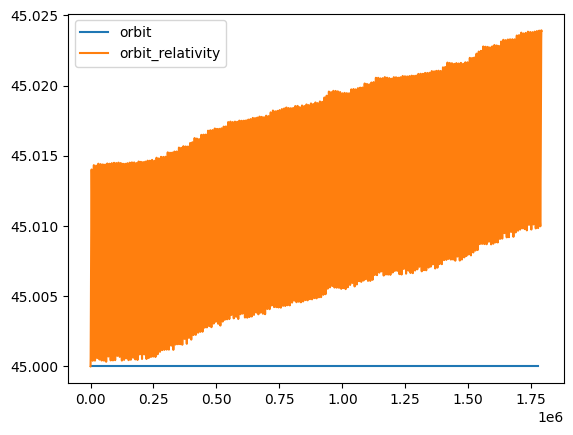

In [22]:
plt.plot(times,inclinations, label="orbit")
plt.plot(orbit_relativity[0],inclinations_relativity, label="orbit_relativity")
plt.legend()

In [23]:
import sys                                                                                                                                                   
sys.path.insert(0, "/Users/ldiaz/Documents/Documentos/otros/thesis_apply/notebooks")
         
from utils.periodogram import lombscargle_from_path

freqs_relativity, powers_relativity, amplitudes_relativity = lombscargle_from_path(orbit_relativity, "OrbitalElements", "inc")
freqs, powers, amplitudes = lombscargle_from_path(orbit, "OrbitalElements", "inc")

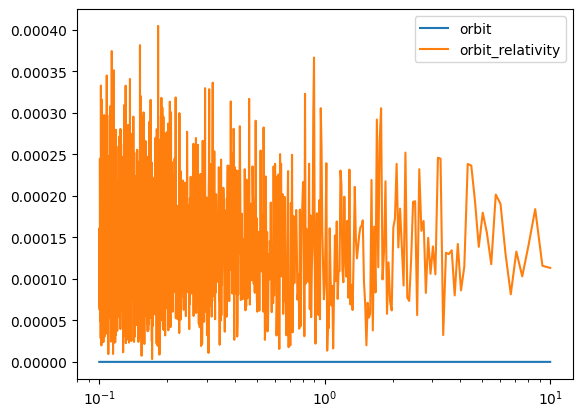

In [24]:
plt.plot(1/freqs, amplitudes, label="orbit")
plt.plot(1/freqs_relativity, amplitudes_relativity, label="orbit_relativity")
plt.xscale("log")
plt.legend()